In [4]:
import zipfile
import io
import os
import numpy as np
import numpy.random as random
import scipy as sp
import pandas as pd
from pandas import Series, DataFrame

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
%matplotlib inline

# Display up to three decimal places
%precision 3

'%.3f'

In [23]:
orders = pd.read_csv("../data/orders.csv")
products = pd.read_csv("../data/products.csv")
returns = pd.read_csv("../data/returns.csv")
shipments = pd.read_csv("../data/shipments.csv")
order_items = pd.read_csv("../data/order_items.csv")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40792\771313658.py:5: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("../data/order_items.csv")


In [55]:
returns.head(10)
returns.sort_values(by='product_id')

,product_id,return_reason,return_quantity,refund_amount
22729,3,changed_mind,7,65029.45
39837,3,changed_mind,8,74960.16
22796,3,not_as_described,4,37875.21
22849,3,wrong_size,1,10737.70
36852,3,wrong_size,2,21053.56
...,...,...,...,...
20206,2412,late_delivery,2,1901.98
20186,2412,changed_mind,2,1950.52
32907,2412,defective,1,1153.54
26687,2412,defective,3,3732.17


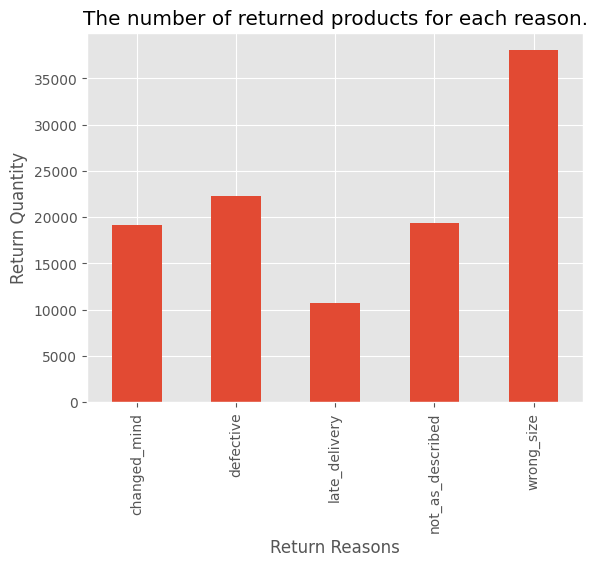

In [33]:
returns = returns[['product_id','return_reason','return_quantity','refund_amount']]
ax = returns.groupby('return_reason').sum()['return_quantity'].plot(kind = 'bar',title ='The number of returned products for each reason.')
ax.set_xlabel("Return Reasons")
ax.set_ylabel("Return Quantity")
plt.show()


Có thể thấy, lý do wrong size là lý do khiến cho khách hàng phải trả lại hàng nhiều nhất (cũng là có số tiền refund lớn nhất). Tại sao? Và sản phẩm nào lại wrong size nhiều nhất?

In [41]:
products.head(10)
products.shape

(2412, 8)

          product_name  return_quantity
119  HanoiStreet RP-80              547
118  HanoiStreet RP-79              529
959   VietMotion UE-06              423
566   SaigonFlex UC-69              422
748      UrbanVN UE-05              416
188  HanoiStreet UE-36              416
668   SaigonFlex UM-92              365
755      UrbanVN UE-14              346
361    MekongFit UE-18              345
600   SaigonFlex UM-01              333


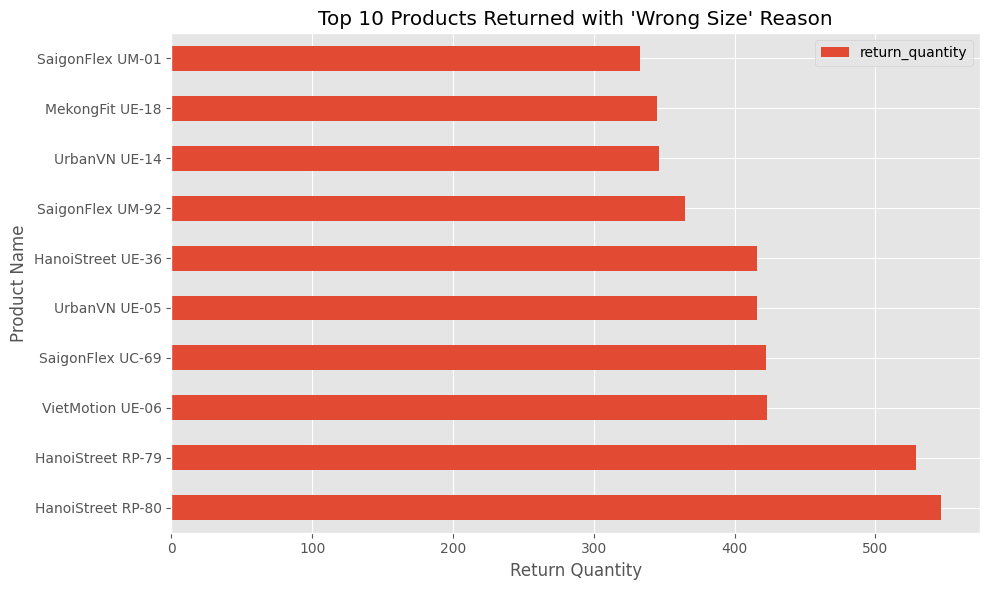

In [65]:
# Find which product is returned the most with "wrong_size" reason
product_wrong_size = products_returns.groupby('product_name', as_index=False)['return_quantity'].sum()
product_wrong_size = product_wrong_size.sort_values(by='return_quantity', ascending=False)
print(product_wrong_size.head(10))

# Or visualize it
ax = product_wrong_size.head(10).plot(x='product_name', y='return_quantity', kind='barh', figsize=(10, 6))
ax.set_xlabel("Return Quantity")
ax.set_ylabel("Product Name")
ax.set_title("Top 10 Products Returned with 'Wrong Size' Reason")
plt.tight_layout()
plt.show()

In [67]:
order_items.head(10).dropna(axis=1)

,order_id,product_id,quantity,unit_price,discount_amount
0,1,2400,7,1138.22,0.0
1,2,609,7,10166.25,0.0
2,3,396,3,11220.33,0.0
3,4,635,5,10639.25,0.0
4,6,1935,1,1597.84,0.0
5,7,1934,6,1633.49,0.0
6,8,1934,6,1602.92,0.0
7,8,1935,4,1642.51,0.0
8,9,1432,8,4049.64,0.0
9,10,1431,5,3977.37,0.0
